# Exploratory Data Analysis (EDA)
#### Exploratory Data Analysis (EDA) is an analysis approach that identifies general patterns in the data. These patterns include outliers and features of the data that might be unexpected.

## Importing the libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Importing the dataset

In [ ]:
dataset = pd.read_csv("Bank_Customers.csv")
X = dataset.iloc[:, 3:-1]
y = dataset.iloc[:, -1]

#### Identifier features such as RowNumber, CustomerId, and Surname(first 3 columns) were excluded from modeling and EDA visualizations, as they are unique to each customer and do not contain behavioral or financial information relevant for predicting customer churn.



## Distribution of the Target Variable (Exited)

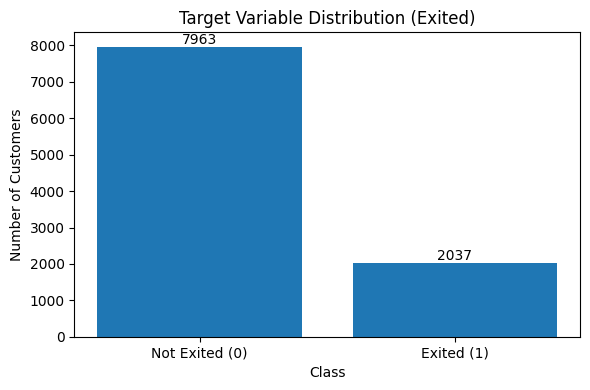

In [ ]:
# Count target classes
counts = dataset["Exited"].value_counts().sort_index()  # ensures order: 0 then 1
labels = ["Not Exited (0)", "Exited (1)"]

# Plot
plt.figure(figsize=(6, 4))
plt.bar(labels, counts.values)
plt.title("Target Variable Distribution (Exited)")
plt.xlabel("Class")
plt.ylabel("Number of Customers")

for i, v in enumerate(counts.values):
    plt.text(i, v, str(v), ha="center", va="bottom")

plt.tight_layout()
plt.show()


####This plot shows the distribution of the target variable Exited, where class 0 represents customers who did not exit and class 1 represents customers who exited the bank. The dataset is imbalanced, with 7,963 customers (79.6%) in the non-exited class and 2,037 customers (20.4%) in the exited class.

####This class imbalance may bias the neural network toward the majority class, making accuracy alone an unreliable evaluation metric. Therefore, additional metrics such as precision, recall, F1-score, and ROC-AUC will be considered during model evaluation.

##Age Distribution by Customer Churn

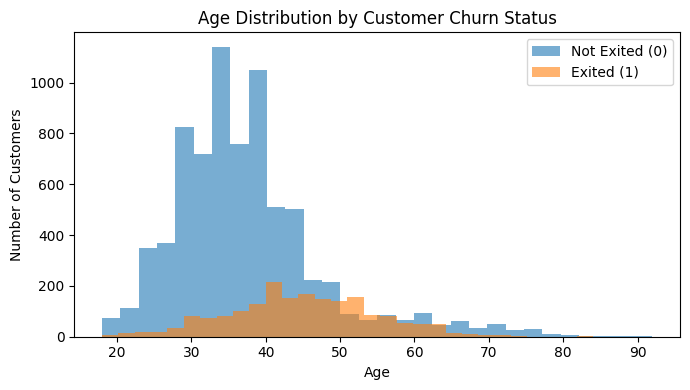

In [ ]:
# Separate age by churn status
age_not_exited = dataset[dataset["Exited"] == 0]["Age"]
age_exited = dataset[dataset["Exited"] == 1]["Age"]

plt.figure(figsize=(7, 4))

plt.hist(age_not_exited, bins=30, alpha=0.6, label="Not Exited (0)")
plt.hist(age_exited, bins=30, alpha=0.6, label="Exited (1)")

plt.title("Age Distribution by Customer Churn Status")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.legend()

plt.tight_layout()
plt.show()


####This plot illustrates the age distribution of customers grouped by churn status. Customers who did not exit are concentrated mainly between the ages of 30 and 40, while customers who exited are more prevalent in higher age ranges, particularly above 40 years. The distribution for exited customers is shifted to the right and exhibits a longer tail, indicating that older customers are more likely to churn. This suggests that age is an important feature for predicting customer churn.

##Account Balance by Customer Churn

7963 2037


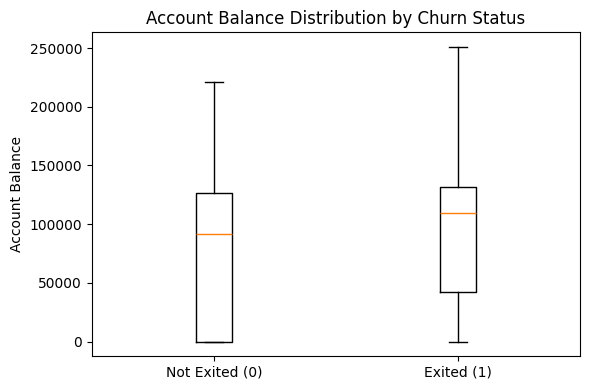

In [ ]:
# Split Balance by churn status
balance_not_exited = dataset.loc[dataset["Exited"] == 0, "Balance"]
balance_exited = dataset.loc[dataset["Exited"] == 1, "Balance"]

# Boxplot
plt.figure(figsize=(6, 4))
plt.boxplot(
    [balance_not_exited.dropna(), balance_exited.dropna()],
    tick_labels=["Not Exited (0)", "Exited (1)"]
)
plt.title("Account Balance Distribution by Churn Status")
plt.ylabel("Account Balance")
plt.tight_layout()
plt.show()


####This plot shows the distribution of account balances for exited and non-exited customers. Non-exited customers have a median balance of approximately 90,000, with the lower quartile at 0, indicating that at least 25% of retained customers maintain no account balance. In contrast, exited customers exhibit a higher median balance of approximately 110,000, and a wider interquartile range, reflecting greater variability in balances.

####Additionally, exited customers reach higher maximum balance values (above 250,000) compared to non-exited customers (approximately 220,000). These observations suggest that customers with higher and more variable account balances are more likely to churn, indicating that account balance may be a significant predictive feature in the churn classification task.

##Credit Score Distribution by Customer Churn

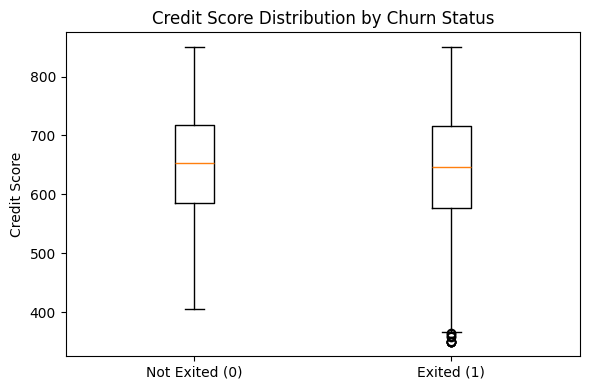

In [ ]:
# Split CreditScore by churn status
credit_not_exited = dataset.loc[dataset["Exited"] == 0, "CreditScore"]
credit_exited = dataset.loc[dataset["Exited"] == 1, "CreditScore"]

plt.figure(figsize=(6, 4))
plt.boxplot(
    [credit_not_exited.dropna(), credit_exited.dropna()],
    tick_labels=["Not Exited (0)", "Exited (1)"]
)

plt.title("Credit Score Distribution by Churn Status")
plt.ylabel("Credit Score")

plt.tight_layout()
plt.show()


####This plot shows the distribution of credit scores for customers who exited and those who did not. Both groups have similar median credit scores and comparable spreads, indicating that credit score values are generally alike regardless of churn status. However, several low credit score outliers are observed among exited customers, suggesting that very low credit scores may be associated with a higher likelihood of churn. Overall, credit score appears to have a weaker relationship with customer churn compared to other features such as age and account balance.

##Customer Churn by Geography

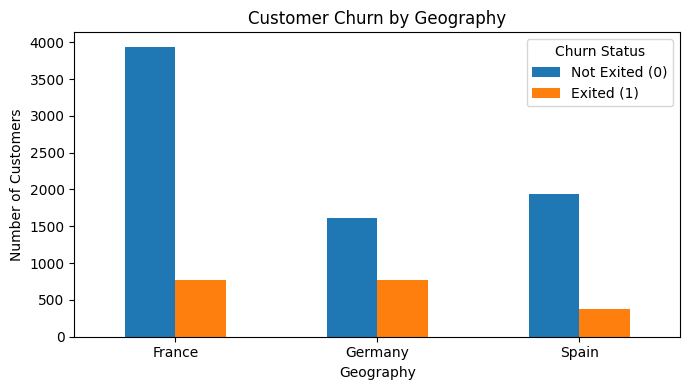

In [ ]:
# Count customers by Geography and Exited
geo_churn = dataset.groupby(["Geography", "Exited"]).size().unstack()

# Plot (grouped bar chart)
geo_churn.plot(kind="bar", figsize=(7, 4))

plt.title("Customer Churn by Geography")
plt.xlabel("Geography")
plt.ylabel("Number of Customers")
plt.legend(["Not Exited (0)", "Exited (1)"], title="Churn Status")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()



####This plot illustrates customer churn across different geographical regions. France has the largest number of customers overall, with the majority not exiting, although a noticeable number of customers still churn. Germany shows a relatively higher number of exited customers compared to its total customer base, indicating a higher churn tendency in this region. In contrast, Spain has the lowest number of exited customers, suggesting comparatively better customer retention. These differences highlight geography as a potentially important factor in predicting customer churn.

##Customer Churn by Gender

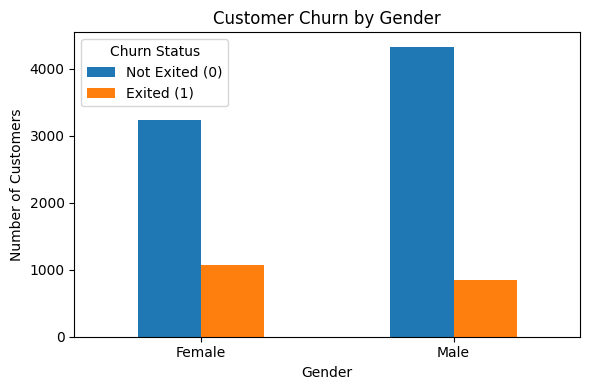

In [ ]:
# Count customers by Gender and Exited
gender_churn = dataset.groupby(["Gender", "Exited"]).size().unstack()

# Plot (grouped bar chart)
gender_churn.plot(kind="bar", figsize=(6, 4))

plt.title("Customer Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.legend(["Not Exited (0)", "Exited (1)"], title="Churn Status")

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


####This plot presents customer churn distribution by gender. While both male and female customers are more likely to remain with the bank, female customers show a higher number of churn cases compared to male customers. This indicates that female customers have a relatively higher churn tendency in the dataset. As a result, gender may be a relevant categorical feature for predicting customer churn and should be considered during model training.

##EDA Summary

####The exploratory data analysis revealed several important patterns related to customer churn. The target variable analysis showed a clear class imbalance, with a smaller proportion of customers exiting compared to those who remained. Age and account balance exhibited noticeable differences between exited and non-exited customers, indicating that older customers and those with higher account balances are more likely to churn. In contrast, credit score showed similar distributions across churn statuses, suggesting a weaker relationship with customer churn. Additionally, categorical features such as geography and gender demonstrated varying churn behaviors across groups, highlighting their potential relevance in predicting churn.

####These findings motivate the use of a neural network model, as customer churn is influenced by a combination of numerical and categorical features with potentially non-linear interactions. Neural networks are well-suited to capture such complex relationships and can effectively learn patterns from scaled numerical variables and encoded categorical features, making them an appropriate choice for this classification task.